# 03 — Salsa Dance Motion Autoencoder

We train a **vanilla GRU autoencoder** on Salsa dance motion sequences, using the same architecture as the Salsa motion representation in SalsaAgent project. 

**Data:** Salsa dance in InterHuman representation, 262 dims, 19-frame windows.



#### Set up Drive and dependencies when running on Google Colab
Othersie, skip the following two cells.

In [ ]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# change the working directory
repo_url = "https://github.com/pjyazdian/VQVAE-INN-Workshop.git"
repo_name = "VQVAE-INN-Workshop"
repo_path = f"/content/drive/MyDrive/{repo_name}"
%cd {repo_path}

## Imports and setup

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*pyarrow.deserialize.*deprecated.*")
import os

import torch
import numpy as np
from pathlib import Path
from Salsa_utils.salsa_utils import (
    get_salsa_model,
    get_salsa_loaders,
    SalsaAETrainer,
    scatter_latent_salsa,
    plot_motion_frame,
    animate_skeleton_3d_gif,
)

SALSA_ROOT = Path("/localhome/pjomeyaz/Payam_Files/Misc/VQ-Workshop/VQVAE-INN-Workshop/data/Salsa_Data")

## Load data


In [3]:
seq_len, input_dim = 19, 262  # InterHuman: window_size-1 frames, 262 dims
train_loader, val_loader = get_salsa_loaders(
    salsa_root=SALSA_ROOT,
    representation_type="interhuman",
    window_size=20,
    stride=10,
    batch_size=32,
    num_workers=0,
    use_both_roles=True,
    normalize=True,
)
print("Train batches:", len(train_loader), ", Val batches:", len(val_loader))
# Inspect one batch
batch = next(iter(train_loader))
print("Batch shape:", batch.shape)  # (B, 19, 262)

Loading cached windows from /localhome/pjomeyaz/Payam_Files/Misc/VQ-Workshop/VQVAE-INN-Workshop/data/Salsa_Data/lmdb_val_interhuman_20frames_cache...
Loaded 900 motion windows from cache.
Using both leader and follower: 1800 total training samples.
Loading normalization statistics from /localhome/pjomeyaz/Payam_Files/Misc/VQ-Workshop/VQVAE-INN-Workshop/data/Salsa_Data/lmdb_val_interhuman_20frames_cache/normalization_stats_interhuman.pkl...
Loading cached windows from /localhome/pjomeyaz/Payam_Files/Misc/VQ-Workshop/VQVAE-INN-Workshop/data/Salsa_Data/lmdb_val_interhuman_20frames_cache...
Loaded 900 motion windows from cache.
Using both leader and follower: 1800 total training samples.
Loading normalization statistics from /localhome/pjomeyaz/Payam_Files/Misc/VQ-Workshop/VQVAE-INN-Workshop/data/Salsa_Data/lmdb_val_interhuman_20frames_cache/normalization_stats_interhuman.pkl...
Train batches: 57 , Val batches: 57
Batch shape: torch.Size([32, 19, 262])


## Visualize: 3D skeleton animation

Animate a sample as a dancing skeleton (saved as GIF). Uses plot_3d_motion from Salsa motion representation.

Motion shape: (19, 262)
Saved: salsa_sample.gif


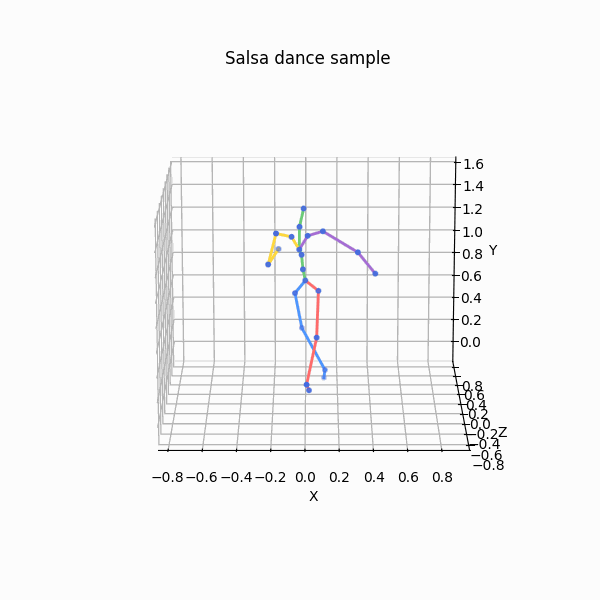

In [4]:
# Pick a sample and animate as 3D skeleton
sample = next(iter(train_loader))
motion = sample[0].numpy()  # (19, 262)
print("Motion shape:", motion.shape)
ds = train_loader.dataset
mean = ds.mean.numpy() if ds.mean is not None else None
std = ds.std.numpy() if ds.std is not None else None
animate_skeleton_3d_gif(
    motion,
    save_path="salsa_sample.gif",
    representation_type="interhuman",
    mean=mean,
    std=std,
    title="Salsa dance sample",
    fps=20,
)

## Model and training

Vanilla GRU AE matching Salsa architecture: bidirectional encoder, autoregressive decoder.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_salsa_model(
    input_dim=input_dim,
    hidden_dim=512,
    num_layers=2,
    latent_dim=512,
    seq_len=seq_len,
    dropout=0.1,
)
trainer = SalsaAETrainer(model, train_loader, val_loader, learning_rate=2e-4, device=device)
trainer.run(n_epochs=50)

/localhome/pjomeyaz/anaconda3/envs/motionagent/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


====> Epoch: 1 Train loss: 0.8490
====> Epoch: 1 Val loss: 0.8089


====> Epoch: 2 Train loss: 0.7717
====> Epoch: 2 Val loss: 0.7132


KeyboardInterrupt: 

#### Load / Save Checkpoints
We load the pretrained model to skip training.

In [ ]:
# Save model checkpoint

# os.makedirs("pretrained", exist_ok=True)
save_path = os.path.join("pretrained", "vanila_Salsa.pt")
# torch.save(model.state_dict(), save_path)
# print(f"Model saved to {save_path}")

# Load model checkpoint (example)
model.load_state_dict(torch.load(save_path, map_location=device))
print("Model loaded from", save_path)

Model loaded from pretrained/vanila_Salsa.pt


## Reconstruction

Compare original vs reconstructed motion. Animate both as 3D skeletons (GIF).

Saved: salsa_original.gif


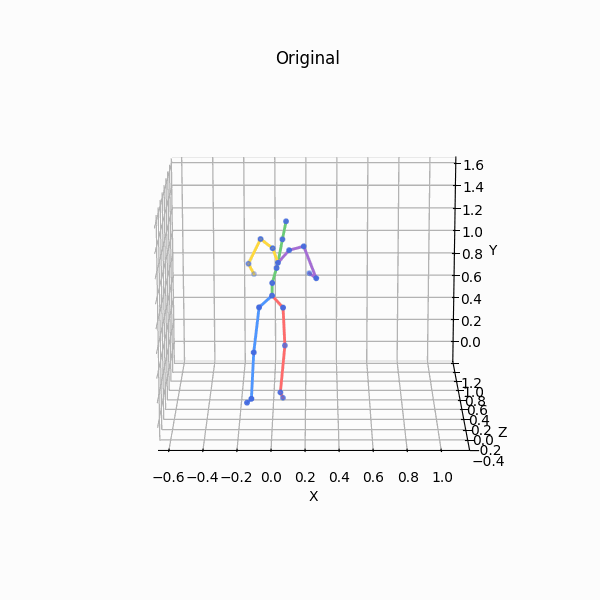

Saved: salsa_reconstructed.gif


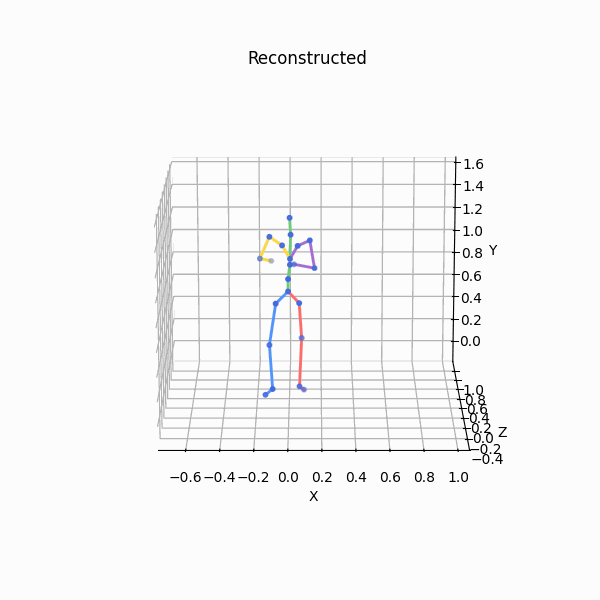

In [8]:
idx = 1
model.eval()
with torch.no_grad():
    sample = val_loader.dataset[idx]  # (19, 262) tensor
    data = sample.unsqueeze(0).to(device)
    recon, _, _, z = model(data)
orig = data[0].cpu().numpy()
recon_np = recon[0].cpu().numpy()
ds = val_loader.dataset
norm_mean = ds.mean.numpy() if ds.mean is not None else None
norm_std = ds.std.numpy() if ds.std is not None else None
# 3D skeleton animations (GIF)
animate_skeleton_3d_gif(orig, "salsa_original.gif", "interhuman", norm_mean, norm_std, "Original", fps=15)
animate_skeleton_3d_gif(recon_np, "salsa_reconstructed.gif", "interhuman", norm_mean, norm_std, "Reconstructed", fps=15)

## Latent space

Encode validation set and visualize with t-SNE.

Latents shape: (1800, 512)


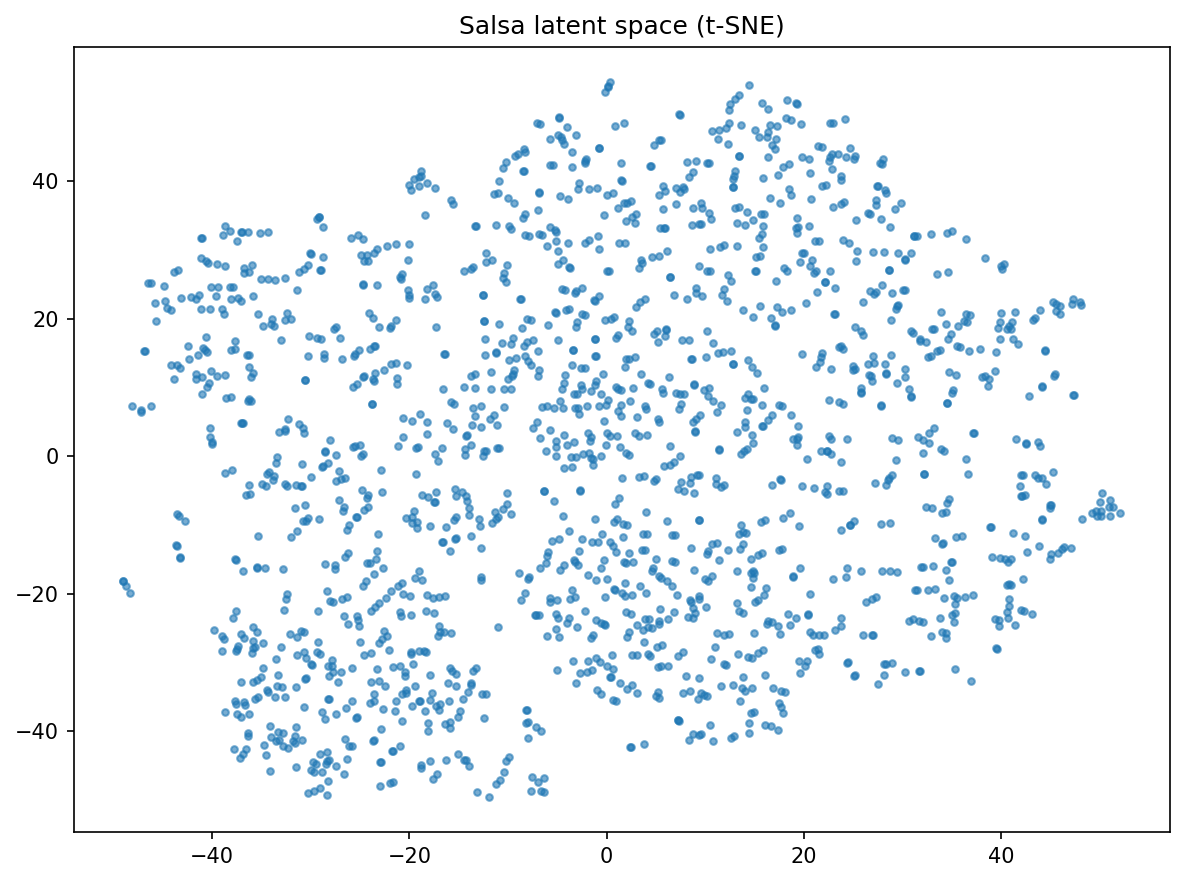

In [9]:
model.eval()
latents = []
n_batches, counter = 200, 0
with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)
        z, mean, logvar = model.inference_encode(batch)
        latents.append(z.cpu().numpy())
        if counter >= n_batches:
             break
        else:
             counter += 1
latents = np.concatenate(latents, axis=0)
print("Latents shape:", latents.shape)
scatter_latent_salsa(latents, use_tsne=True, title="Salsa latent space (t-SNE)")

#### KMeans clustering in latent space

Visualize keypoint AE latents colored by KMeans cluster assignments for unsupervised structure.

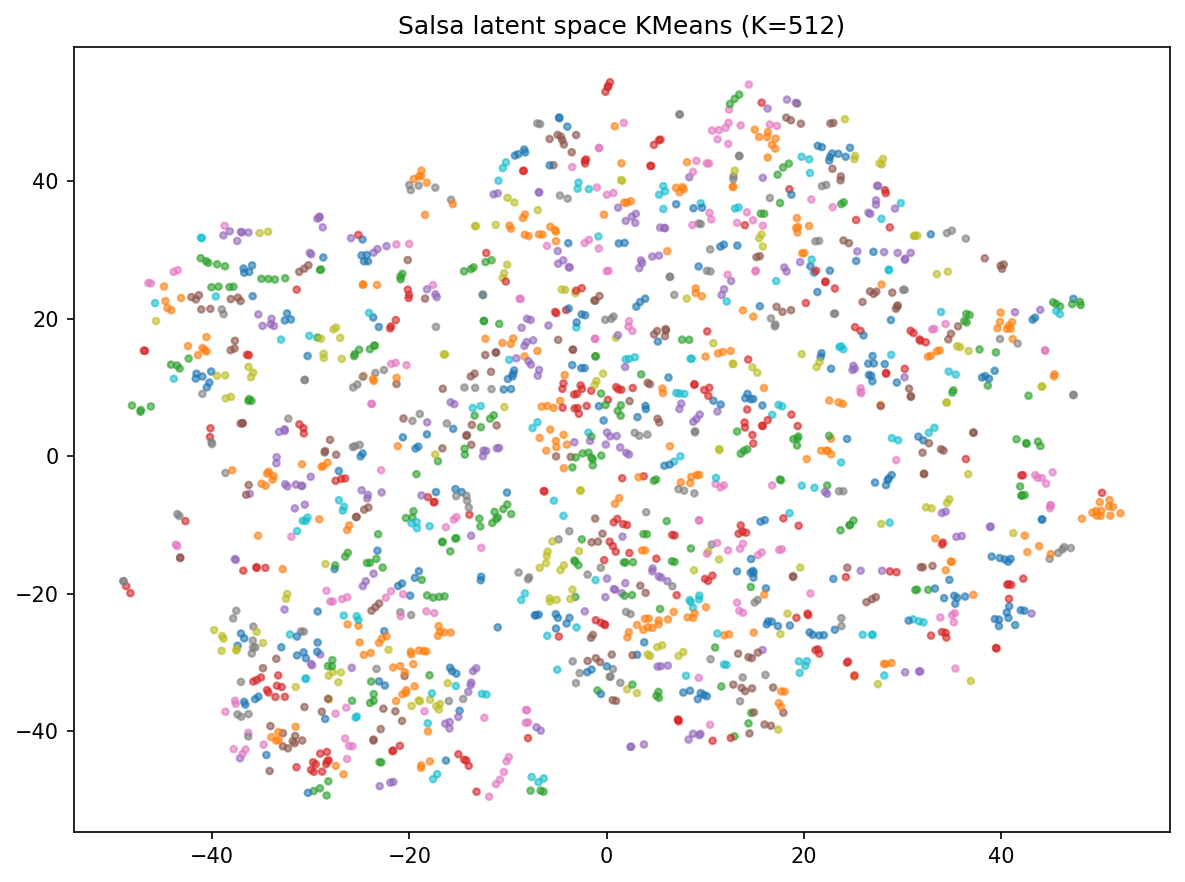

In [10]:
from sklearn.cluster import KMeans

# Run KMeans on the latents
n_clusters = 512
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(latents)

# Scatter plot colored by cluster labels
scatter_latent_salsa(latents, labels=cluster_labels, use_tsne=True, title=f"Salsa latent space KMeans (K={n_clusters})")

## VQ Training (InterHuman)

In [16]:
# VQ-VAE training (reuse existing loaders)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vq = get_salsa_model(
    input_dim=input_dim,
    seq_len=seq_len,
    use_vqvae=True,
    nb_code=512,
    quantizer="ema_reset",
    vq_mu=0.95,
    commit_weight=0.02,
)
trainer_vq = SalsaAETrainer(
    model_vq,
    train_loader,
    val_loader,
    learning_rate=1e-4,
    device=device,
    use_vqvae=True,
    commit_weight=0.02,
    loss_vel_weight=0.1,
    warm_up_epochs=5,
    lr_scheduler_gamma=0.05,
)
trainer_vq.run(n_epochs=50)


====> Epoch: 1 Train loss: 0.7794
====> Epoch: 1 Val loss: 0.7983


KeyboardInterrupt: 

In [17]:

# Save model checkpoint

# os.makedirs("pretrained", exist_ok=True)
save_path = os.path.join("pretrained", "VQ_Salsa.pt")
# torch.save(model_vq.state_dict(), save_path)
# print(f"Model saved to {save_path}")

# Load model checkpoint (example)
model_vq.load_state_dict(torch.load(save_path, map_location=device))
print("Model loaded from", save_path)

Model loaded from pretrained/VQ_Salsa.pt


## Reconstruction (VQ model)

Saved: salsa_vq_original.gif


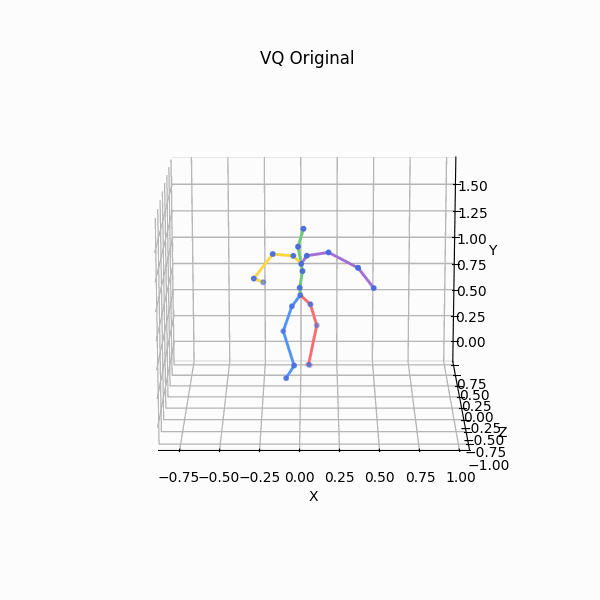

Saved: salsa_vq_reconstructed.gif


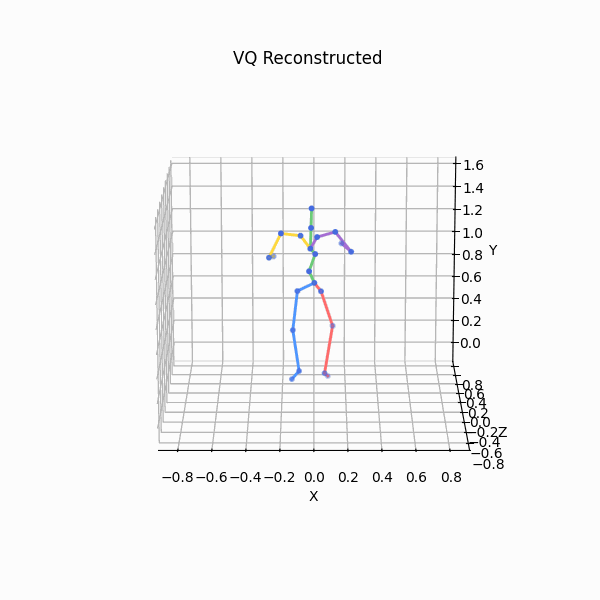

In [18]:
idx = 0
model_vq.eval()
with torch.no_grad():
    sample = val_loader.dataset[idx]  # (19, 262) tensor
    data = sample.unsqueeze(0).to(device)
    out = model_vq(data)
    recon_vq = out[0] if isinstance(out, (tuple, list)) else out
orig = data[0].cpu().numpy()
recon_vq_np = recon_vq[0].cpu().numpy()
ds = val_loader.dataset
norm_mean = ds.mean.numpy() if ds.mean is not None else None
norm_std = ds.std.numpy() if ds.std is not None else None
animate_skeleton_3d_gif(orig, "salsa_vq_original.gif", "interhuman", norm_mean, norm_std, "VQ Original", fps=15)
animate_skeleton_3d_gif(recon_vq_np, "salsa_vq_reconstructed.gif", "interhuman", norm_mean, norm_std, "VQ Reconstructed", fps=15)

## Latent space (colored by VQ code index)

VQ latents shape: (1800, 512) | labels shape: (1800,)


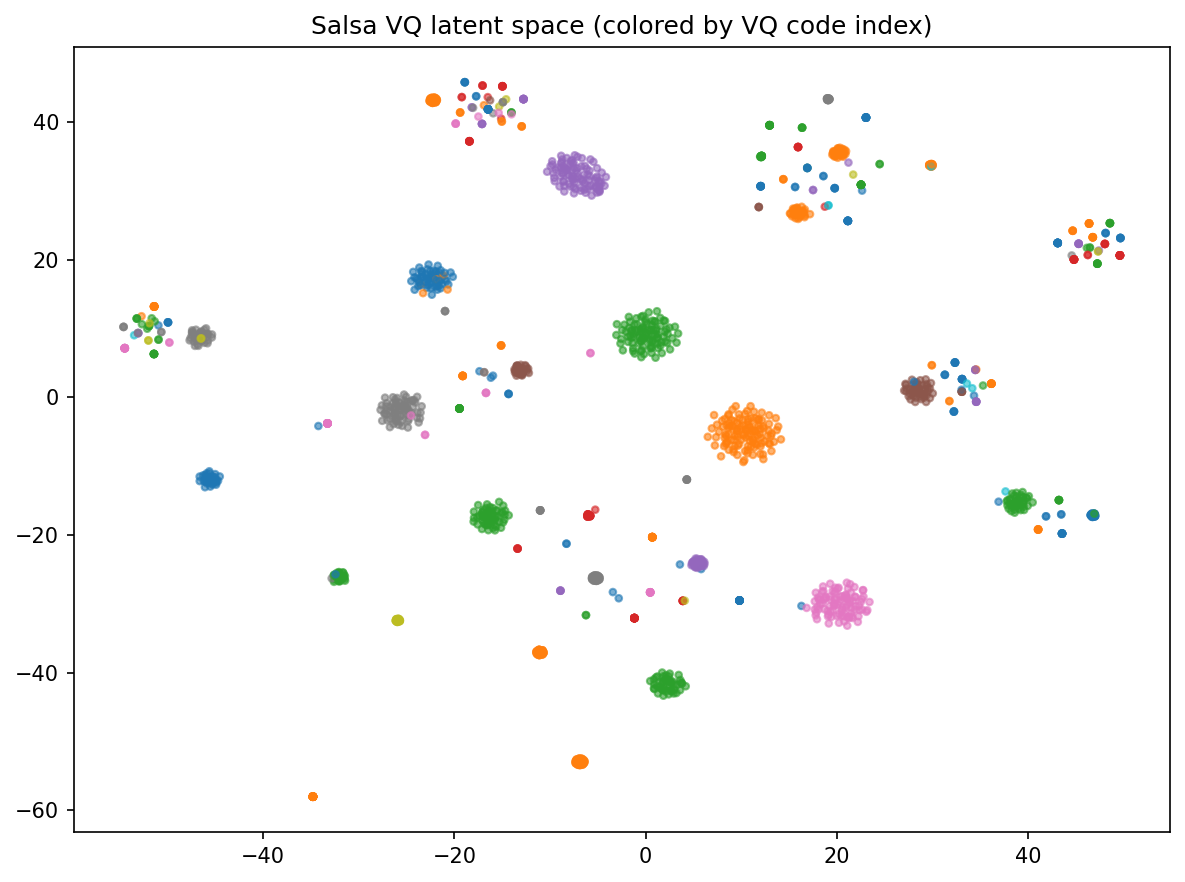

In [19]:
model_vq.eval()
latents_vq, vq_labels = [], []
n_batches, counter = 100, 0
with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)
        enc_out = model_vq.inference_encode(batch)
        z = enc_out[0] if isinstance(enc_out, (tuple, list)) else enc_out
        latents_vq.append(z.cpu().numpy())
        # VQ code indices from encoder latents
        code_idx = model_vq.vq_layer.quantize(z)
        vq_labels.append(code_idx.cpu().numpy())
        if counter >= n_batches:
            break
        counter += 1
latents_vq = np.concatenate(latents_vq, axis=0)
vq_labels = np.concatenate(vq_labels, axis=0)
print("VQ latents shape:", latents_vq.shape, "| labels shape:", vq_labels.shape)
scatter_latent_salsa(latents_vq, labels=vq_labels, use_tsne=True, title="Salsa VQ latent space (colored by VQ code index)")

#### Visualize clustered samples
Visualize several samples from same cluster

Found 3 samples with VQ code index 3
Saved: salsa_vq_cluster_3_0.gif


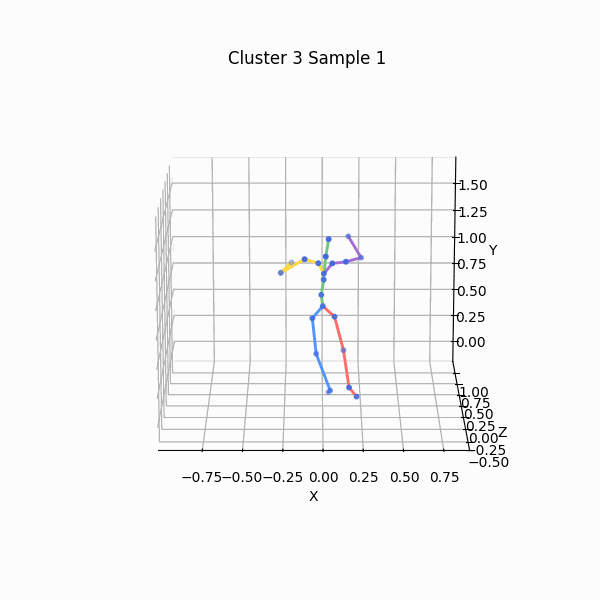

Saved: salsa_vq_cluster_3_1.gif


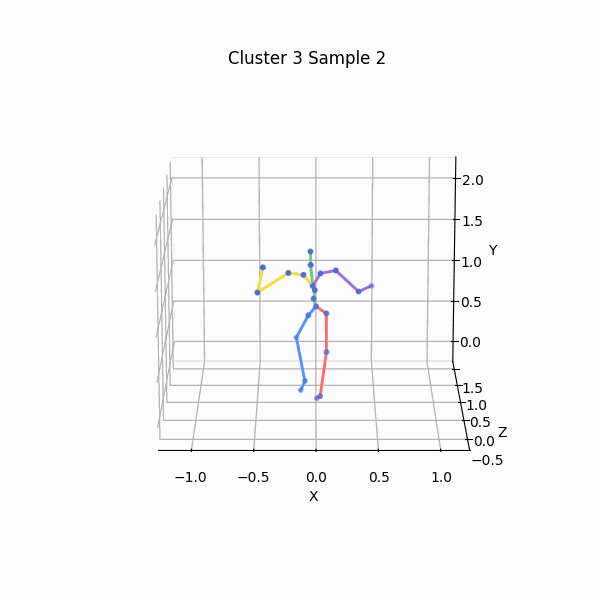

Saved: salsa_vq_cluster_3_2.gif


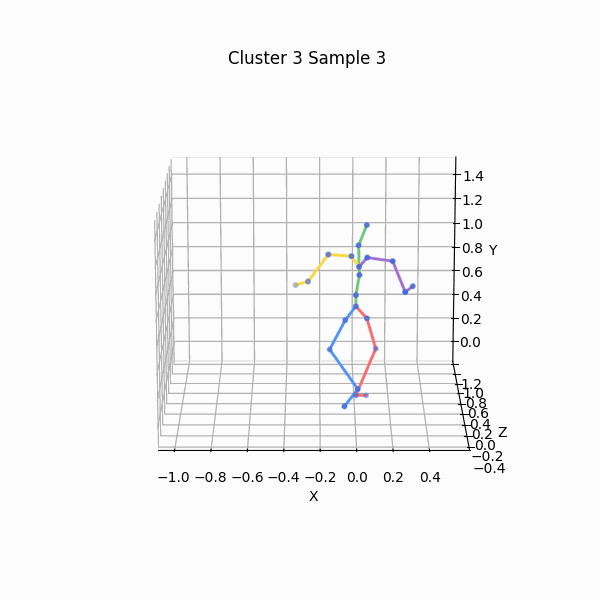

In [30]:
selected_code = 3  # example code index to search for
n_samples = 3
found = 0
selected_samples = []

with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)
        z = model_vq.inference_encode(batch)
        vq_idx = model_vq.vq_layer.quantize(z if not isinstance(z, (tuple, list)) else z[0])
        for i in range(batch.size(0)):
            if vq_idx[i].item() == selected_code:
                selected_samples.append(batch[i].cpu())
                found += 1
                if found == n_samples:
                    break
        if found == n_samples:
            break

print(f"Found {found} samples with VQ code index {selected_code}")

for i, sample in enumerate(selected_samples):
    orig = sample.numpy()
    animate_skeleton_3d_gif(orig, f"salsa_vq_cluster_{selected_code}_{i}.gif",
                            "interhuman", norm_mean, norm_std, 
                            f"Cluster {selected_code} Sample {i+1}", fps=15)